In [20]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import nflreadpy as nfl
import sys
sys.path.append('..')
from utils import compute_current_elo, compute_current_team_stats

model = joblib.load('../models/logreg_win_probability.pkl')

In [21]:
# Pulls the current season's full schedule including played and unplayed games

current_season = 2026
schedule = nfl.load_schedules([current_season]).to_pandas()

completed = schedule.dropna(subset=['home_score', 'away_score'])
upcoming = schedule[schedule['home_score'].isna()].copy()

print(f'{len(completed)} completed games, {len(upcoming)} upcoming games')

33 completed games, 239 upcoming games


In [22]:
# Builds each team's current rolling stats and elo based on games played so far

current_stats = compute_current_team_stats(completed, N=5)
current_elo = compute_current_elo(completed)

print(current_stats.head())
print(current_elo.head())

  team  roll_pf    roll_pa  roll_winpct
0  ARI     16.5  22.500000     0.500000
1  ATL     17.0  22.666667     0.333333
2  BAL     29.0  23.500000     0.500000
3  BUF     38.5  31.000000     1.000000
4  CAR     35.5  31.000000     0.500000
  team          elo
0  SEA  1520.000000
1   LA  1500.575011
2  CAR  1500.000000
3  CIN  1519.424989
4  DET  1500.000000


In [23]:
# Attaches home and away stats

upcoming = upcoming.merge(
    current_stats.rename(columns={
        'team': 'home_team',
        'roll_pf': 'home_roll_pf',
        'roll_pa': 'home_roll_pa',
        'roll_winpct': 'home_roll_winpct'
    }),
    on='home_team', how='left'
)

upcoming = upcoming.merge(
    current_stats.rename(columns={
        'team': 'away_team',
        'roll_pf': 'away_roll_pf',
        'roll_pa': 'away_roll_pa',
        'roll_winpct': 'away_roll_winpct'
    }),
    on='away_team', how='left'
)

In [24]:
# Attaches Elo ratings

upcoming = upcoming.merge(
    current_elo.rename(columns={
        'team': 'home_team',
        'elo': 'home_elo',
    }),
    on='home_team', how='left'
)
upcoming = upcoming.merge(
    current_elo.rename(columns={
        'team': 'away_team',
        'elo': 'away_elo',
    }),
    on='away_team', how='left'
)

In [25]:
print(upcoming[['home_team', 'away_team', 'home_roll_pf', 'away_roll_pf', 'home_elo', 'away_elo']].head())

  home_team away_team  home_roll_pf  away_roll_pf     home_elo     away_elo
0       BUF       LAC          38.5          14.0  1520.000000  1480.575011
1       CLE       CAR          16.5          35.5  1500.000000  1500.000000
2       DET       NYJ          31.0          20.0  1500.000000  1499.424989
3       IND       HOU          26.5          18.5  1480.575011  1480.575011
4       JAX        NE          23.5          15.0  1499.424989  1500.575011


In [26]:
# Predicts win probabilities

feature_cols = [
    'home_roll_pf',
    'home_roll_pa',
    'home_roll_winpct',
    'away_roll_pf',
    'away_roll_pa',
    'away_roll_winpct',
    'home_elo',
    'away_elo'
]

upcoming = upcoming.dropna(subset=feature_cols)
upcoming['home_win_prob'] = model.predict_proba(upcoming[feature_cols])[:, 1]

upcoming[['week', 'home_team', 'away_team', 'home_win_prob']]

,week,home_team,away_team,home_win_prob
0,3,BUF,LAC,0.783688
1,3,CLE,CAR,0.355049
2,3,DET,NYJ,0.576594
3,3,IND,HOU,0.503274
4,3,JAX,NE,0.661290
...,...,...,...,...
234,18,MIN,CHI,0.600890
235,18,NE,MIA,0.673257
236,18,NO,TB,0.602355
237,18,NYG,PHI,0.449144


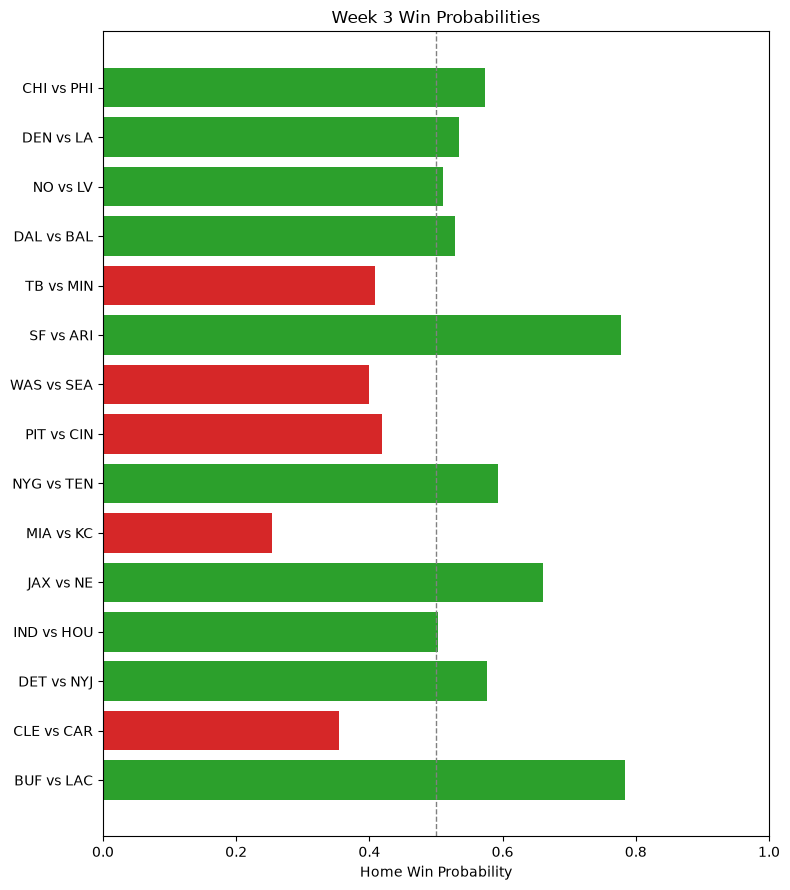

In [28]:
# Plots win probabilites for a given week

plotted_week = 3 # set manually by e.g., plotted_week = 4 
week_games = upcoming[upcoming['week'] == plotted_week]

fig, ax = plt.subplots(figsize=(8, len(week_games) * 0.6))
labels = week_games['home_team'] + " vs " + week_games['away_team']
colors = ['#2ca02c' if p >= 0.5 else '#d62728' for p in week_games['home_win_prob']]

ax.barh(labels, week_games['home_win_prob'], color=colors)
ax.axvline(0.5, color='gray', linestyle = '--', linewidth=1)
ax.set_xlabel('Home Win Probability')
ax.set_xlim(0,1)
ax.set_title(f'Week {plotted_week} Win Probabilities')
plt.tight_layout()
plt.show()